# Exploration des fichiers ClimateNet (.nc)
Ce notebook explore la structure, les variables et la distribution des classes dans les fichiers NetCDF de ClimateNet.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import glob
from tqdm import tqdm


print('Imports OK')

Imports OK


In [3]:
FILE_PATH = '../climatenet/train/data-1996-06-09-01-1_0.nc'  # data/climatenet/train/data-1996-06-09-01-1_0.nc

ds = xr.open_dataset(FILE_PATH)

print('=== STRUCTURE DU FICHIER ===')
print(ds)
print()
print('=== DIMENSIONS ===')
print(dict(ds.dims))
print()
print('=== VARIABLES ===')
for var in ds.data_vars:
    print(f'  {var}: shape={ds[var].shape}, dtype={ds[var].dtype}')

=== STRUCTURE DU FICHIER ===
<xarray.Dataset> Size: 64MB
Dimensions:  (time: 1, lat: 768, lon: 1152)
Coordinates:
  * time     (time) <U23 92B 'data-1996-06-09-01-1.nc'
  * lat      (lat) float64 6kB -90.0 -89.77 -89.53 -89.3 ... 89.53 89.77 90.0
  * lon      (lon) float64 9kB 0.0 0.3125 0.625 0.9375 ... 359.1 359.4 359.7
Data variables: (12/17)
    TMQ      (time, lat, lon) float32 4MB ...
    U850     (time, lat, lon) float32 4MB ...
    V850     (time, lat, lon) float32 4MB ...
    UBOT     (time, lat, lon) float32 4MB ...
    VBOT     (time, lat, lon) float32 4MB ...
    QREFHT   (time, lat, lon) float32 4MB ...
    ...       ...
    TS       (time, lat, lon) float32 4MB ...
    TREFHT   (time, lat, lon) float32 4MB ...
    Z1000    (time, lat, lon) float32 4MB ...
    Z200     (time, lat, lon) float32 4MB ...
    ZBOT     (time, lat, lon) float32 4MB ...
    LABELS   (lat, lon) int64 7MB ...

=== DIMENSIONS ===
{'time': 1, 'lat': 768, 'lon': 1152}

=== VARIABLES ===
  TMQ: shape=(

/var/folders/xk/vbrlq_ms0f36v65nyhxw_c_h0000gn/T/ipykernel_29717/1868885172.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(dict(ds.dims))


## Exploration des labels (LABELS)

In [4]:
labels = ds['LABELS'].values  # shape: (time, lat, lon)

print(f'Shape des labels : {labels.shape}')
print(f'Valeurs uniques  : {np.unique(labels)}')
print()

# Comptage global
total = labels.size
for cls, name in [(0, 'Background'), (1, 'Tropical Cyclone'), (2, 'Atmospheric River')]:
    count = np.sum(labels == cls)
    print(f'  Classe {cls} ({name:20s}): {count:>12,} pixels  ({100*count/total:.2f}%)')

Shape des labels : (768, 1152)
Valeurs uniques  : [0 1 2]

  Classe 0 (Background          ):      817,294 pixels  (92.38%)
  Classe 1 (Tropical Cyclone    ):        3,750 pixels  (0.42%)
  Classe 2 (Atmospheric River   ):       63,692 pixels  (7.20%)


In [ ]:
TRAIN_DIR = '../climatenet/train/'
TOTAL_PIXELS = 768 * 1152 

files = sorted(glob.glob(f'{TRAIN_DIR}*.nc'))
print(f'Nombre de fichiers train trouvés : {len(files)}')


Nombre de fichiers train trouvés : 398


In [ ]:
records = []
 
for f in tqdm(files, desc='Analyse des fichiers'):
    ds = xr.open_dataset(f)
    labels = ds['LABELS'].values.flatten()
    ds.close()
 
    n_bg = int(np.sum(labels == 0))
    n_tc = int(np.sum(labels == 1))
    n_ar = int(np.sum(labels == 2))
 
    records.append({
        'filename': Path(f).name,
        'n_bg': n_bg,
        'n_tc': n_tc,
        'n_ar': n_ar,
        'pct_bg': 100 * n_bg / TOTAL_PIXELS,
        'pct_tc': 100 * n_tc / TOTAL_PIXELS,
        'pct_ar': 100 * n_ar / TOTAL_PIXELS,
        'has_tc': n_tc > 0,
        'has_ar': n_ar > 0,
        'has_both': (n_tc > 0) and (n_ar > 0),
        'only_bg': (n_tc == 0) and (n_ar == 0),
    })
 
df = pd.DataFrame(records)
df.to_csv('train_class_distribution.csv', index=False)
print(f'Analyse terminée — {len(df)} fichiers traités')
print(f'Sauvegardé dans train_class_distribution.csv\n')

Analyse des fichiers: 100%|██████████| 398/398 [00:04<00:00, 93.02it/s]

✅ Analyse terminée — 398 fichiers traités
💾 Sauvegardé dans train_class_distribution.csv



In [ ]:
print('=' * 55)
print('RÉSUMÉ GLOBAL')
print('=' * 55)
print(f"Total fichiers           : {len(df)}")
print(f"Fichiers SANS TC ni AR   : {df['only_bg'].sum():>5}  ({100*df['only_bg'].mean():.1f}%)  ← Background pur")
print(f"Fichiers avec TC         : {df['has_tc'].sum():>5}  ({100*df['has_tc'].mean():.1f}%)")
print(f"Fichiers avec AR         : {df['has_ar'].sum():>5}  ({100*df['has_ar'].mean():.1f}%)")
print(f"Fichiers avec TC ET AR   : {df['has_both'].sum():>5}  ({100*df['has_both'].mean():.1f}%)")
 
print()
print('=' * 55)
print('TOTAUX PIXELS (tous fichiers confondus)')
print('=' * 55)
total_bg = df['n_bg'].sum()
total_tc = df['n_tc'].sum()
total_ar = df['n_ar'].sum()
grand_total = total_bg + total_tc + total_ar
print(f"Background       : {total_bg:>15,}  ({100*total_bg/grand_total:.3f}%)")
print(f"Tropical Cyclone : {total_tc:>15,}  ({100*total_tc/grand_total:.3f}%)")
print(f"Atmospheric River: {total_ar:>15,}  ({100*total_ar/grand_total:.3f}%)")
print(f"\nRatio BG / TC    : {total_bg/max(total_tc,1):>8.0f}x")
print(f"Ratio BG / AR    : {total_bg/max(total_ar,1):>8.0f}x")

RÉSUMÉ GLOBAL
Total fichiers           : 398
Fichiers SANS TC ni AR   :     0  (0.0%)  ← Background pur
Fichiers avec TC         :   331  (83.2%)
Fichiers avec AR         :   397  (99.7%)
Fichiers avec TC ET AR   :   330  (82.9%)

TOTAUX PIXELS (tous fichiers confondus)
Background       :     330,520,699  (93.865%)
Tropical Cyclone :       1,626,347  (0.462%)
Atmospheric River:      19,977,882  (5.674%)

Ratio BG / TC    :      203x
Ratio BG / AR    :       17x


In [ ]:
print()
print('=' * 55)
print('CAS EXTRÊMES')
print('=' * 55)
 
print('\n--- Fichiers BACKGROUND PUR (aucun TC ni AR) ---')
bg_only = df[df['only_bg']].sort_values('pct_bg', ascending=False)
if len(bg_only) == 0:
    print('  → Aucun fichier 100% Background !')
else:
    print(f'  {len(bg_only)} fichiers Background pur :')
    print(bg_only[['filename', 'pct_bg']].to_string(index=False))
 
print('\n--- TOP 10 fichiers avec le PLUS de TC ---')
top_tc = df[df['has_tc']].sort_values('n_tc', ascending=False).head(10)
print(top_tc[['filename', 'n_tc', 'pct_tc', 'n_ar', 'pct_ar']].to_string(index=False))
 
print('\n--- TOP 10 fichiers avec le PLUS de AR ---')
top_ar = df[df['has_ar']].sort_values('n_ar', ascending=False).head(10)
print(top_ar[['filename', 'n_ar', 'pct_ar', 'n_tc', 'pct_tc']].to_string(index=False))
 
print('\n--- Fichiers avec TC TRÈS RARE (< 0.1% pixels TC) ---')
rare_tc = df[(df['has_tc']) & (df['pct_tc'] < 0.1)].sort_values('pct_tc')
print(f'  {len(rare_tc)} fichiers avec TC très rare (<0.1%)')
if len(rare_tc) > 0:
    print(rare_tc[['filename', 'pct_tc', 'pct_ar']].head(10).to_string(index=False))


CAS EXTRÊMES

--- Fichiers BACKGROUND PUR (aucun TC ni AR) ---
  → Aucun fichier 100% Background !

--- TOP 10 fichiers avec le PLUS de TC ---
                 filename  n_tc   pct_tc  n_ar   pct_ar
data-2008-09-19-01-1_1.nc 26467 2.991514 10228 1.156051
data-2002-03-31-01-1_1.nc 19799 2.237843 23234 2.626094
data-2010-09-09-01-1_1.nc 17813 2.013369 45858 5.183241
data-2009-08-19-01-1_0.nc 17436 1.970757 34813 3.934846
data-2000-01-06-01-1_2.nc 16805 1.899437 58932 6.660970
data-1997-08-14-01-1_2.nc 16213 1.832524 68784 7.774523
data-2000-09-28-01-1_0.nc 15903 1.797485 53851 6.086674
data-1996-09-01-01-1_1.nc 15841 1.790478 28535 3.225256
data-2001-07-12-01-1_5.nc 13976 1.579680 22395 2.531264
data-1996-10-03-01-1_1.nc 13897 1.570751 29729 3.360211

--- TOP 10 fichiers avec le PLUS de AR ---
                 filename   n_ar    pct_ar  n_tc   pct_tc
data-1998-10-28-01-1_0.nc 137001 15.484958     0 0.000000
data-2006-06-22-01-1_2.nc 134800 15.236183  4017 0.454034
data-2001-10-20-01-1_1

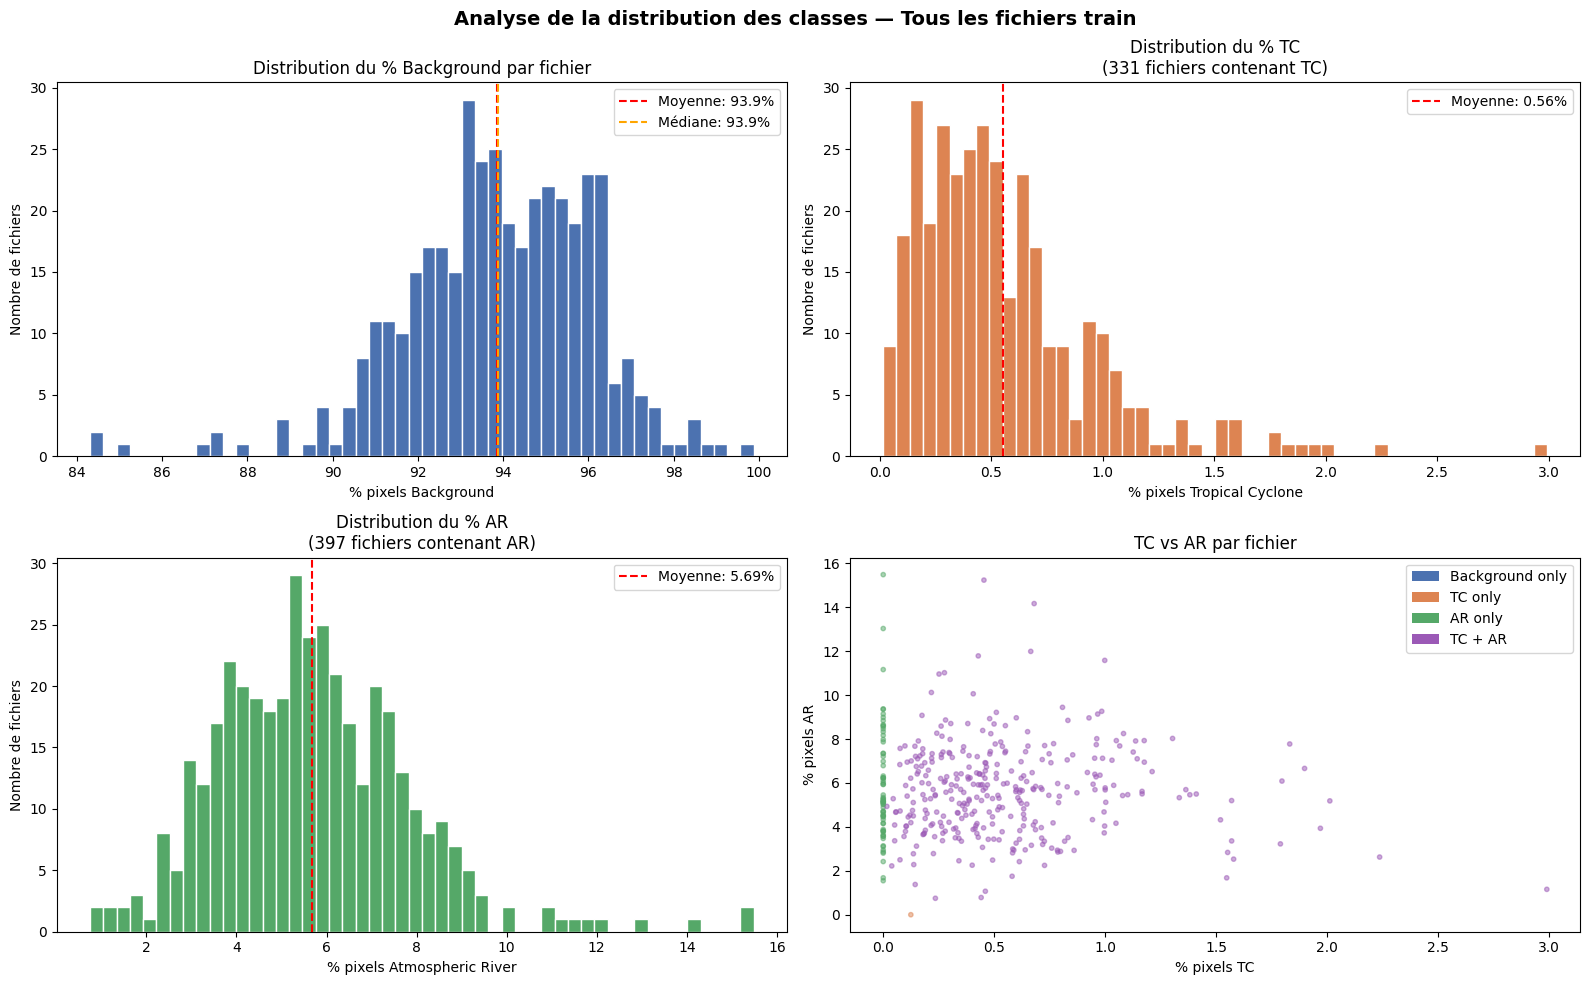


✅ Graphiques sauvegardés dans train_class_distribution.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse de la distribution des classes — Tous les fichiers train',
             fontsize=14, fontweight='bold')
 
# 1. Distribution % Background
axes[0, 0].hist(df['pct_bg'], bins=50, color='#4C72B0', edgecolor='white')
axes[0, 0].set_title('Distribution du % Background par fichier')
axes[0, 0].set_xlabel('% pixels Background')
axes[0, 0].set_ylabel('Nombre de fichiers')
axes[0, 0].axvline(df['pct_bg'].mean(), color='red', linestyle='--',
                   label=f"Moyenne: {df['pct_bg'].mean():.1f}%")
axes[0, 0].axvline(df['pct_bg'].median(), color='orange', linestyle='--',
                   label=f"Médiane: {df['pct_bg'].median():.1f}%")
axes[0, 0].legend()
 
# 2. Distribution % TC (fichiers avec TC uniquement)
tc_files = df[df['has_tc']]
if len(tc_files) > 0:
    axes[0, 1].hist(tc_files['pct_tc'], bins=50, color='#DD8452', edgecolor='white')
    axes[0, 1].set_title(f'Distribution du % TC\n({len(tc_files)} fichiers contenant TC)')
    axes[0, 1].set_xlabel('% pixels Tropical Cyclone')
    axes[0, 1].set_ylabel('Nombre de fichiers')
    axes[0, 1].axvline(tc_files['pct_tc'].mean(), color='red', linestyle='--',
                       label=f"Moyenne: {tc_files['pct_tc'].mean():.2f}%")
    axes[0, 1].legend()
 
# 3. Distribution % AR (fichiers avec AR uniquement)
ar_files = df[df['has_ar']]
if len(ar_files) > 0:
    axes[1, 0].hist(ar_files['pct_ar'], bins=50, color='#55A868', edgecolor='white')
    axes[1, 0].set_title(f'Distribution du % AR\n({len(ar_files)} fichiers contenant AR)')
    axes[1, 0].set_xlabel('% pixels Atmospheric River')
    axes[1, 0].set_ylabel('Nombre de fichiers')
    axes[1, 0].axvline(ar_files['pct_ar'].mean(), color='red', linestyle='--',
                       label=f"Moyenne: {ar_files['pct_ar'].mean():.2f}%")
    axes[1, 0].legend()
 
# 4. Scatter TC vs AR par fichier
def get_color(row):
    if row['has_both']:
        return '#9B59B6'
    elif row['has_tc']:
        return '#DD8452'
    elif row['has_ar']:
        return '#55A868'
    else:
        return '#4C72B0'
 
colors_scatter = df.apply(get_color, axis=1)
axes[1, 1].scatter(df['pct_tc'], df['pct_ar'], c=colors_scatter, alpha=0.5, s=10)
axes[1, 1].set_title('TC vs AR par fichier')
axes[1, 1].set_xlabel('% pixels TC')
axes[1, 1].set_ylabel('% pixels AR')
legend_elements = [
    mpatches.Patch(facecolor='#4C72B0', label='Background only'),
    mpatches.Patch(facecolor='#DD8452', label='TC only'),
    mpatches.Patch(facecolor='#55A868', label='AR only'),
    mpatches.Patch(facecolor='#9B59B6', label='TC + AR'),
]
axes[1, 1].legend(handles=legend_elements)
 
plt.tight_layout()
plt.savefig('train_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Graphiques sauvegardés dans train_class_distribution.png')

In [17]:
SHAPE = (768, 1152)  # lat × lon
 
# Accumulateurs — on somme les labels sur tous les fichiers
# pour chaque pixel (lat, lon)
count_tc = np.zeros(SHAPE, dtype=np.int32)   # nb de fois où pixel = TC
count_ar = np.zeros(SHAPE, dtype=np.int32)   # nb de fois où pixel = AR
count_bg = np.zeros(SHAPE, dtype=np.int32)   # nb de fois où pixel = BG

In [ ]:
# ============================================================
# ÉTAPE 1 — Accumulation sur tous les fichiers
# ============================================================
for f in tqdm(files, desc='Accumulation des labels'):
    ds = xr.open_dataset(f)
    labels = ds['LABELS'].values  # shape (768, 1152)
    ds.close()
 
    count_tc += (labels == 1).astype(np.int32)
    count_ar += (labels == 2).astype(np.int32)
    count_bg += (labels == 0).astype(np.int32)
 
print('Accumulation terminée')
 
# Sauvegarde pour réutilisation
np.save('count_tc.npy', count_tc)
np.save('count_ar.npy', count_ar)
np.save('count_bg.npy', count_bg)
print('Matrices sauvegardées (count_tc.npy, count_ar.npy, count_bg.npy)')

Accumulation des labels: 100%|██████████| 398/398 [00:04<00:00, 88.61it/s]

✅ Accumulation terminée
💾 Matrices sauvegardées (count_tc.npy, count_ar.npy, count_bg.npy)


In [20]:
# ============================================================
# ÉTAPE 2 — Analyse des zones
# ============================================================
never_tc = count_tc == 0        # pixels qui n'ont JAMAIS eu de TC
never_ar = count_ar == 0        # pixels qui n'ont JAMAIS eu de AR
never_event = never_tc & never_ar  # pixels qui n'ont JAMAIS eu ni TC ni AR
always_bg = count_bg == len(files) # pixels qui sont TOUJOURS BG
 
total_pixels = SHAPE[0] * SHAPE[1]
 
print()
print('=' * 55)
print('ANALYSE DES ZONES PERMANENTES')
print('=' * 55)
print(f'Total pixels par grille    : {total_pixels:>10,}')
print()
print(f'Jamais TC (sur {len(files)} fichiers)  : {never_tc.sum():>10,}  ({100*never_tc.mean():.1f}%)')
print(f'Jamais AR (sur {len(files)} fichiers)  : {never_ar.sum():>10,}  ({100*never_ar.mean():.1f}%)')
print(f'Jamais TC ni AR            : {never_event.sum():>10,}  ({100*never_event.mean():.1f}%)')
print(f'Toujours BG                : {always_bg.sum():>10,}  ({100*always_bg.mean():.1f}%)')
print()
# Fréquence maximale de TC/AR par pixel
max_tc_freq = count_tc.max()
max_ar_freq = count_ar.max()
print(f'Pixel le plus souvent TC   : {max_tc_freq} fois / {len(files)} fichiers ({100*max_tc_freq/len(files):.1f}%)')
print(f'Pixel le plus souvent AR   : {max_ar_freq} fois / {len(files)} fichiers ({100*max_ar_freq/len(files):.1f}%)')


ANALYSE DES ZONES PERMANENTES
Total pixels par grille    :    884,736

Jamais TC (sur 398 fichiers)  :    632,388  (71.5%)
Jamais AR (sur 398 fichiers)  :    269,588  (30.5%)
Jamais TC ni AR            :    247,154  (27.9%)
Toujours BG                :    247,154  (27.9%)

Pixel le plus souvent TC   : 65 fois / 398 fichiers (16.3%)
Pixel le plus souvent AR   : 165 fois / 398 fichiers (41.5%)


In [21]:
# ============================================================
# ÉTAPE 3 — Masque potentiel (zones jamais actives)
# ============================================================
print()
print('=' * 55)
print('MASQUE POTENTIEL')
print('=' * 55)
 
# Réduction possible si on ignore les zones jamais actives
reduction = 100 * never_event.mean()
print(f'En ignorant les zones jamais actives :')
print(f'  → On peut ignorer {reduction:.1f}% des pixels BG')
print(f'  → Il reste {100-reduction:.1f}% de la grille à prédire')


MASQUE POTENTIEL
En ignorant les zones jamais actives :
  → On peut ignorer 27.9% des pixels BG
  → Il reste 72.1% de la grille à prédire


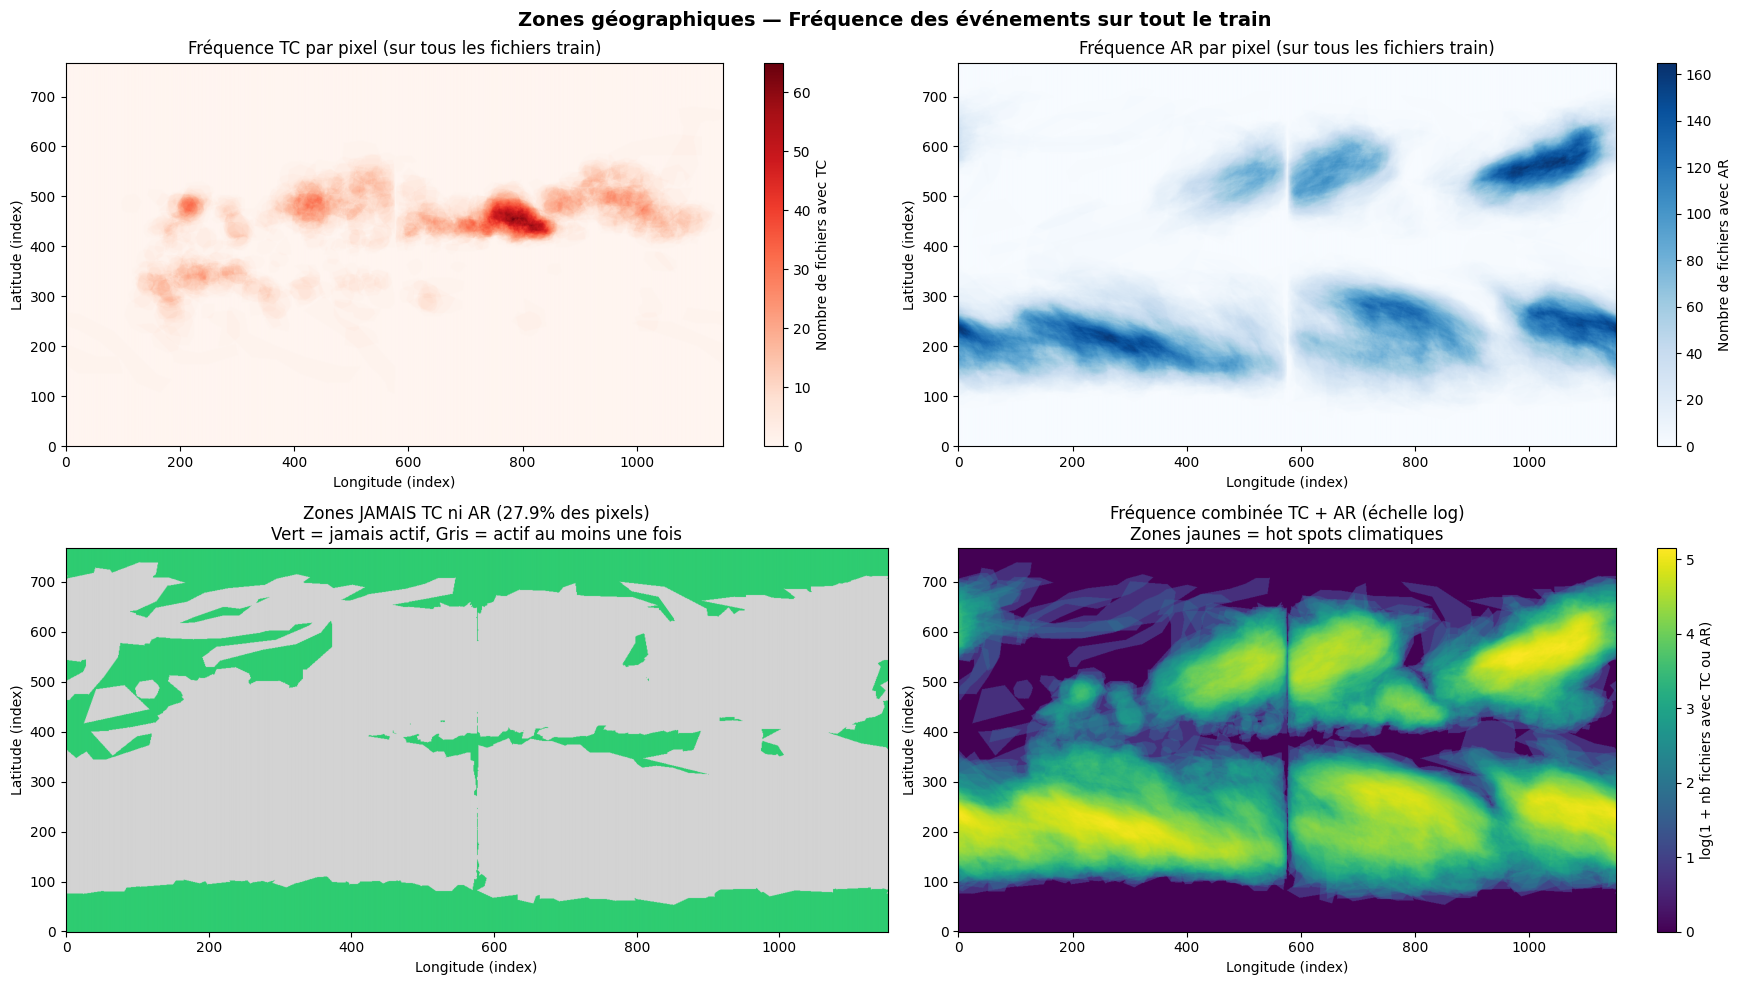


✅ Graphiques sauvegardés dans geographic_zones_analysis.png


In [ ]:
# ============================================================
# ÉTAPE 4 — Visualisations
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Zones géographiques — Fréquence des événements sur tout le train',
             fontsize=14, fontweight='bold')
 
# 1. Fréquence TC par pixel (heatmap)
im1 = axes[0, 0].imshow(count_tc, origin='lower', cmap='Reds', aspect='auto')
plt.colorbar(im1, ax=axes[0, 0], label='Nombre de fichiers avec TC')
axes[0, 0].set_title('Fréquence TC par pixel (sur tous les fichiers train)')
axes[0, 0].set_xlabel('Longitude (index)')
axes[0, 0].set_ylabel('Latitude (index)')
 
# 2. Fréquence AR par pixel (heatmap)
im2 = axes[0, 1].imshow(count_ar, origin='lower', cmap='Blues', aspect='auto')
plt.colorbar(im2, ax=axes[0, 1], label='Nombre de fichiers avec AR')
axes[0, 1].set_title('Fréquence AR par pixel (sur tous les fichiers train)')
axes[0, 1].set_xlabel('Longitude (index)')
axes[0, 1].set_ylabel('Latitude (index)')
 
# 3. Carte des zones JAMAIS actives
cmap3 = mcolors.ListedColormap(['#d3d3d3', '#2ecc71'])
axes[1, 0].imshow(never_event.astype(int), origin='lower',
                  cmap=cmap3, aspect='auto', vmin=0, vmax=1)
axes[1, 0].set_title(f'Zones JAMAIS TC ni AR ({100*never_event.mean():.1f}% des pixels)\n'
                     f'Vert = jamais actif, Gris = actif au moins une fois')
axes[1, 0].set_xlabel('Longitude (index)')
axes[1, 0].set_ylabel('Latitude (index)')
 
# 4. Fréquence combinée TC + AR (log scale)
combined = count_tc + count_ar
im4 = axes[1, 1].imshow(np.log1p(combined), origin='lower',
                         cmap='viridis', aspect='auto')
plt.colorbar(im4, ax=axes[1, 1], label='log(1 + nb fichiers avec TC ou AR)')
axes[1, 1].set_title('Fréquence combinée TC + AR (échelle log)\n'
                      'Zones jaunes = hot spots climatiques')
axes[1, 1].set_xlabel('Longitude (index)')
axes[1, 1].set_ylabel('Latitude (index)')
 
plt.tight_layout()
plt.savefig('geographic_zones_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Graphiques sauvegardés dans geographic_zones_analysis.png')

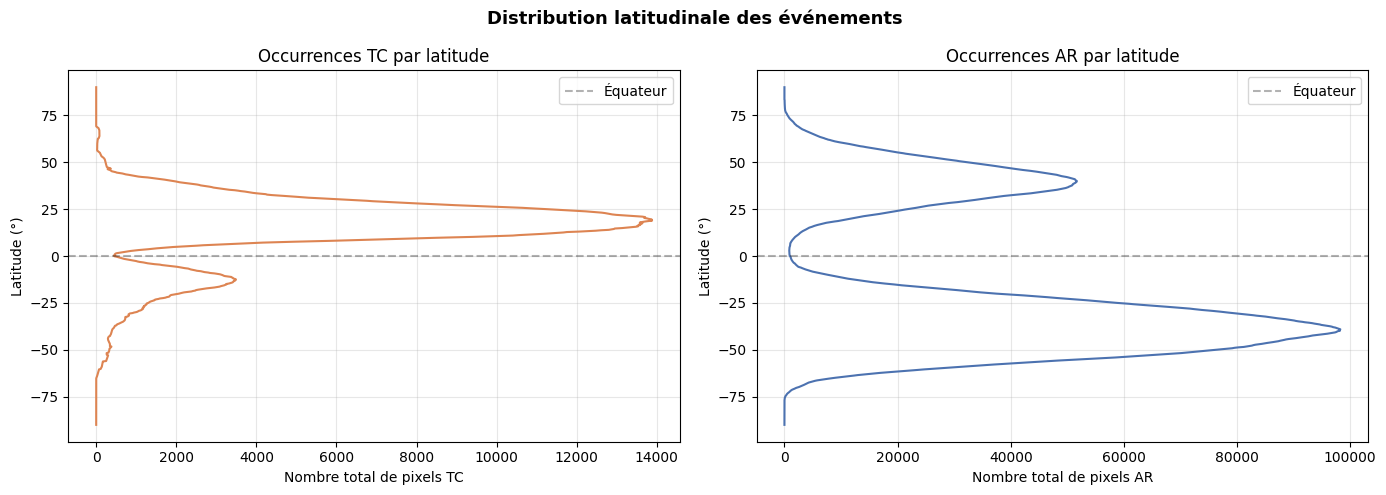

✅ Distribution latitudinale sauvegardée dans latitudinal_distribution.png


In [ ]:
# ============================================================
# ÉTAPE 5 — Distribution latitudinale
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Distribution latitudinale des événements', fontsize=13, fontweight='bold')
 
lat_values = np.linspace(-90, 90, SHAPE[0])
 
# TC par latitude
tc_per_lat = count_tc.sum(axis=1)  # somme sur les longitudes
axes2[0].plot(tc_per_lat, lat_values, color='#DD8452', linewidth=1.5)
axes2[0].set_title('Occurrences TC par latitude')
axes2[0].set_xlabel('Nombre total de pixels TC')
axes2[0].set_ylabel('Latitude (°)')
axes2[0].axhline(0, color='black', linestyle='--', alpha=0.3, label='Équateur')
axes2[0].legend()
axes2[0].grid(alpha=0.3)
 
# AR par latitude
ar_per_lat = count_ar.sum(axis=1)
axes2[1].plot(ar_per_lat, lat_values, color='#4C72B0', linewidth=1.5)
axes2[1].set_title('Occurrences AR par latitude')
axes2[1].set_xlabel('Nombre total de pixels AR')
axes2[1].set_ylabel('Latitude (°)')
axes2[1].axhline(0, color='black', linestyle='--', alpha=0.3, label='Équateur')
axes2[1].legend()
axes2[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('latitudinal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Distribution latitudinale sauvegardée dans latitudinal_distribution.png')
 